* [MPG Dataset (Miles Per Gallon)](#mpg)
    * [Preprocessing](#preprocessing)
        * [A. Encoding :](#encoding) OneHotEncoder
        * [B. Feature Engineering :](#feature-engineering) PolynomialFeatures
        * [C. Normalisation :](#normalisation) MinMaxScaler, StandardScaler
        * [D. Feature Selection :](#feature-selection) SelectKBest, f_regression
        * [E. Pipeline Sklearn :](#pipeline) ColumnTransformer, Pipeline

<a id="pipeline"></a>

## <span style="color:black">**MPG Dataset** (Miles Per Gallon)</span>

#### <span style="color:black">**Preprocessing**</span>

In [71]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy

import sklearn
print("sklearn version : ", sklearn.__version__)

from sklearn import set_config
set_config(transform_output = "pandas")

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, LabelBinarizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.datasets import make_regression

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

sklearn version :  1.8.0


In [72]:
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [73]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


1. Éliminer les lignes contenant des valeurs manquantes.

In [74]:
mpg.dropna(axis=0, inplace=True)
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [75]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


2. Séparer le jeu de données en X/y (y est la variable mpg et X tout le reste).

In [76]:
X = mpg.drop(columns=["mpg"])
y = mpg["mpg"]

In [77]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [78]:
pd.DataFrame(y.head())

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [79]:
print(f"{X.shape=}")
print(f"{y.shape=}")

X.shape=(392, 8)
y.shape=(392,)


3. Séparer le jeu de données en trainset et testset (en écrivant  `train_test_split(X, y)`).

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


print(f"{X_train.shape=}")
print(f"{X_test.shape=}")
print(f"{y_train.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(313, 8)
X_test.shape=(79, 8)
y_train.shape=(313,)
y_test.shape=(79,)


4. Extraire le constructeur automobile de la variable name et mettre le résultat dans une variable "constructor" (si vous l'ignorez, mettez "other"), puis éliminer la colonne "name".

In [81]:
X_train["constructor"] = (
    X_train["name"]
        .str.lower()
        .str.split()
        .str[0]
)

X_test["constructor"] = (
    X_test["name"]
        .str.lower()
        .str.split()
        .str[0]
)

print(f"{X_train["constructor"]}")
print(f"{X_test["constructor"]}")

220      datsun
256    plymouth
301    plymouth
193        ford
57       toyota
         ...   
325          vw
194         amc
118        opel
48         ford
174        ford
Name: constructor, Length: 313, dtype: object
146         dodge
282          ford
69     oldsmobile
378      plymouth
331        subaru
          ...    
101      plymouth
65           ford
56       plymouth
262     chevrolet
216         honda
Name: constructor, Length: 79, dtype: object


In [82]:
sorted(X_train["constructor"].unique())

['amc',
 'audi',
 'bmw',
 'buick',
 'cadillac',
 'capri',
 'chevrolet',
 'chevy',
 'chrysler',
 'datsun',
 'dodge',
 'fiat',
 'ford',
 'hi',
 'honda',
 'maxda',
 'mazda',
 'mercedes',
 'mercedes-benz',
 'mercury',
 'nissan',
 'oldsmobile',
 'opel',
 'peugeot',
 'plymouth',
 'pontiac',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'toyouta',
 'triumph',
 'vokswagen',
 'volkswagen',
 'volvo',
 'vw']

In [83]:
sorted(X_train[X_train["constructor"].str.startswith(
    tuple(list("pqrst"))
)]["constructor"].unique())

['peugeot',
 'plymouth',
 'pontiac',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'toyouta',
 'triumph']

In [84]:
constructor_mapping = {
    "capri": "ford",
    "ford": "ford",
    "chevroelt": "chevrolet",
    "chevrolet": "chevrolet",
    "chevy": "chevrolet",
    "hi": "other",
    "maxda": "mazda",
    "mazda": "mazda",
    "mercedes": "mercedes",
    "mercedes-benz": "mercedes",
    "toyota": "toyota",
    "toyouta": "toyota",
    "vw": "volkswagen",
    "volkswagen": "volkswagen",
    "volswagen": "volkswagen",
    "vokswagen": "volkswagen"
}

In [85]:
X_train["constructor"] = X_train["constructor"].replace(constructor_mapping)
X_test["constructor"]  = X_test["constructor"].replace(constructor_mapping)

In [86]:
X_train["constructor"] = X_train["constructor"].fillna("other")
X_test["constructor"]  = X_test["constructor"].fillna("other")

In [87]:
X_train["constructor"].value_counts()

constructor
ford          39
chevrolet     34
plymouth      24
dodge         22
datsun        22
amc           22
toyota        21
volkswagen    16
pontiac       15
buick         11
mercury       11
mazda         10
oldsmobile     9
honda          8
peugeot        7
chrysler       6
audi           6
volvo          5
fiat           5
opel           4
subaru         3
saab           3
bmw            2
renault        2
mercedes       2
nissan         1
cadillac       1
triumph        1
other          1
Name: count, dtype: int64

In [88]:
X_test["constructor"].value_counts()

constructor
chevrolet     13
ford          10
plymouth       7
dodge          6
volkswagen     6
buick          6
honda          5
toyota         5
amc            5
fiat           3
mazda          2
oldsmobile     1
subaru         1
mercedes       1
pontiac        1
cadillac       1
saab           1
audi           1
volvo          1
renault        1
peugeot        1
datsun         1
Name: count, dtype: int64

In [89]:
print(f"{X_train.head()}")
print(f"{X_test.head()}")

     cylinders  displacement  horsepower  weight  acceleration  model_year  \
220          4          85.0        70.0    1945          16.8          77   
256          6         225.0       100.0    3430          17.2          78   
301          4         105.0        70.0    2200          13.2          79   
193          6         200.0        81.0    3012          17.6          76   
57           4         113.0        95.0    2278          15.5          72   

    origin                   name constructor  
220  japan  datsun f-10 hatchback      datsun  
256    usa        plymouth volare    plymouth  
301    usa       plymouth horizon    plymouth  
193    usa          ford maverick        ford  
57   japan  toyota corona hardtop      toyota  
     cylinders  displacement  horsepower  weight  acceleration  model_year  \
146          4          90.0        75.0    2125          14.5          74   
282          4         140.0        88.0    2890          17.3          79   
69       

In [90]:
# Regroupons les constructeurs rares (<10) en 'other' (se base sur le train) :
counts = X_train["constructor"].value_counts()
common = counts[counts >= 10].index

X_train["constructor"] = X_train["constructor"].where(
    X_train["constructor"].isin(common), 
    "other"
)
X_test["constructor"] = X_test["constructor"].where(
    X_test["constructor"].isin(common), 
    "other"
)

In [91]:
X_train["constructor"].value_counts()

constructor
other         66
ford          39
chevrolet     34
plymouth      24
datsun        22
dodge         22
amc           22
toyota        21
volkswagen    16
pontiac       15
mercury       11
buick         11
mazda         10
Name: count, dtype: int64

In [92]:
X_test["constructor"].value_counts()

constructor
other         17
chevrolet     13
ford          10
plymouth       7
dodge          6
volkswagen     6
buick          6
amc            5
toyota         5
mazda          2
pontiac        1
datsun         1
Name: count, dtype: int64

In [93]:
X_train.drop(columns=["name"], inplace=True)
X_test.drop(columns=["name"], inplace=True)

In [94]:
print("name" in X_train.columns)
print("name" in X_test.columns)

False
False


<a id="encoding"></a>

5. Encoder les catégories de la manière la plus pertinente.

In [25]:
encoder_origin = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore"
)

encoder_origin.fit(X_train[["origin"]])
encoder_origin.transform(X_train[["origin"]])[:5]

,origin_japan,origin_usa
220,1.0,0.0
256,0.0,1.0
301,0.0,1.0
193,0.0,1.0
57,1.0,0.0


In [26]:
encoder_constructor = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore"
)

encoder_constructor.fit(X_train[["constructor"]])
encoder_constructor.transform(X_train[["constructor"]])[:5]

,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
193,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
print(f"{X_train.columns}")
print(f"{X_test.columns}")

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'constructor'],
      dtype='object')
Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'origin', 'constructor'],
      dtype='object')


In [28]:
# Transformer train/test (origin + constructor) :
origin_train = encoder_origin.transform(X_train[["origin"]])
origin_test  = encoder_origin.transform(X_test[["origin"]])

constructor_train = encoder_constructor.transform(X_train[["constructor"]])
constructor_test  = encoder_constructor.transform(X_test[["constructor"]])

In [29]:
# Convertir en DataFrame : (IMPORTANT: garder les index)
origin_trained = pd.DataFrame(
    origin_train,
    columns=encoder_origin.get_feature_names_out(["origin"]),
    index=X_train.index
)
origin_tested = pd.DataFrame(
    origin_test,
    columns=encoder_origin.get_feature_names_out(["origin"]),
    index=X_test.index
)

constructor_trained = pd.DataFrame(
    constructor_train,
    columns=encoder_constructor.get_feature_names_out(["constructor"]),
    index=X_train.index
)
constructor_tested = pd.DataFrame(
    constructor_test,
    columns=encoder_constructor.get_feature_names_out(["constructor"]),
    index=X_test.index
)

In [30]:
origin_trained.head()

,origin_japan,origin_usa
220,1.0,0.0
256,0.0,1.0
301,0.0,1.0
193,0.0,1.0
57,1.0,0.0


In [31]:
origin_tested.head()

,origin_japan,origin_usa
146,0.0,1.0
282,0.0,1.0
69,0.0,1.0
378,0.0,1.0
331,1.0,0.0


In [32]:
constructor_trained.head()

,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
193,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [33]:
constructor_tested.head()

,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
146,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
282,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [34]:
# Supprimer les colonnes catégorielles :
X_train = X_train.drop(columns=["origin", "constructor"])
X_test  = X_test.drop(columns=["origin", "constructor"])

# Concaténer les colonnes encodées :
X_train = pd.concat([X_train, origin_trained, constructor_trained], axis=1)
X_test  = pd.concat([X_test,  origin_tested,  constructor_tested],  axis=1)

In [35]:
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
220,4,85.0,70.0,1945,16.8,77,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
256,6,225.0,100.0,3430,17.2,78,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
301,4,105.0,70.0,2200,13.2,79,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
193,6,200.0,81.0,3012,17.6,76,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,4,113.0,95.0,2278,15.5,72,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
X_test.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
146,4,90.0,75.0,2125,14.5,74,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
282,4,140.0,88.0,2890,17.3,79,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69,8,350.0,160.0,4456,13.5,72,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
378,4,105.0,63.0,2125,14.7,82,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
331,4,97.0,67.0,2145,18.0,80,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [37]:
print(X_train.shape, X_test.shape)
print(list(X_train.columns) == list(X_test.columns))

(313, 20) (79, 20)
True


<a id="feature-engineering"></a>

6. Utiliser un Polynomial Feature de degré 2 sur les variables Acceleration, Horsepower et weight.

In [38]:
cols_polynomial = ["acceleration", "horsepower", "weight"]
mpg_polynomial = PolynomialFeatures(degree=2, include_bias=False)

# FIT sur train :
mpg_polynomial.fit(X_train[cols_polynomial])

# TRANSFORM train + test :
X_train_polynomial = mpg_polynomial.transform(X_train[cols_polynomial]).astype(int)
X_test_polynomial  = mpg_polynomial.transform(X_test[cols_polynomial]).astype(int)

In [39]:
X_train_polynomial.head()

,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,16,70,1945,282,1176,32676,4900,136150,3783025
256,17,100,3430,295,1720,58996,10000,343000,11764900
301,13,70,2200,174,924,29040,4900,154000,4840000
193,17,81,3012,309,1425,53011,6561,243972,9072144
57,15,95,2278,240,1472,35309,9025,216410,5189284


In [40]:
X_test_polynomial.head()

,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,14,75,2125,210,1087,30812,5625,159375,4515625
282,17,88,2890,299,1522,49997,7744,254320,8352100
69,13,160,4456,182,2160,60156,25600,712960,19855936
378,14,63,2125,216,926,31237,3969,133875,4515625
331,18,67,2145,324,1206,38610,4489,143715,4601025


In [41]:
# DataFrame avec les bons noms de colonnes :
polynomial_feature_names = mpg_polynomial.get_feature_names_out(cols_polynomial)

X_train_polynomial = pd.DataFrame(X_train_polynomial, columns=polynomial_feature_names, index=X_train.index)
X_test_polynomial  = pd.DataFrame(X_test_polynomial,  columns=polynomial_feature_names, index=X_test.index)

In [42]:
X_train_polynomial.head()

,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,16,70,1945,282,1176,32676,4900,136150,3783025
256,17,100,3430,295,1720,58996,10000,343000,11764900
301,13,70,2200,174,924,29040,4900,154000,4840000
193,17,81,3012,309,1425,53011,6561,243972,9072144
57,15,95,2278,240,1472,35309,9025,216410,5189284


In [43]:
X_test_polynomial.head()

,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,14,75,2125,210,1087,30812,5625,159375,4515625
282,17,88,2890,299,1522,49997,7744,254320,8352100
69,13,160,4456,182,2160,60156,25600,712960,19855936
378,14,63,2125,216,926,31237,3969,133875,4515625
331,18,67,2145,324,1206,38610,4489,143715,4601025


In [44]:
# Drop anciennes colonnes et concat nouvelles :
X_train = X_train.drop(columns=cols_polynomial)
X_test  = X_test.drop(columns=cols_polynomial)

X_train = pd.concat([X_train, X_train_polynomial], axis=1)
X_test  = pd.concat([X_test,  X_test_polynomial],  axis=1)

In [45]:
X_train.head()

,cylinders,displacement,model_year,origin_japan,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,...,constructor_volkswagen,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,4,85.0,77,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,16,70,1945,282,1176,32676,4900,136150,3783025
256,6,225.0,78,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,17,100,3430,295,1720,58996,10000,343000,11764900
301,4,105.0,79,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,13,70,2200,174,924,29040,4900,154000,4840000
193,6,200.0,76,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,17,81,3012,309,1425,53011,6561,243972,9072144
57,4,113.0,72,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,15,95,2278,240,1472,35309,9025,216410,5189284


In [46]:
X_test.head()

,cylinders,displacement,model_year,origin_japan,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,...,constructor_volkswagen,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,4,90.0,74,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,14,75,2125,210,1087,30812,5625,159375,4515625
282,4,140.0,79,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,17,88,2890,299,1522,49997,7744,254320,8352100
69,8,350.0,72,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,13,160,4456,182,2160,60156,25600,712960,19855936
378,4,105.0,82,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,14,63,2125,216,926,31237,3969,133875,4515625
331,4,97.0,80,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,18,67,2145,324,1206,38610,4489,143715,4601025


<a id="normalisation"></a>

7. Normaliser les variables cylinders, model_year, usa, et constructeur avec MinMaxScaler, et les autres variables avec un StandardScaler.

In [47]:
X_train.columns

Index(['cylinders', 'displacement', 'model_year', 'origin_japan', 'origin_usa',
       'constructor_buick', 'constructor_chevrolet', 'constructor_datsun',
       'constructor_dodge', 'constructor_ford', 'constructor_mazda',
       'constructor_mercury', 'constructor_other', 'constructor_plymouth',
       'constructor_pontiac', 'constructor_toyota', 'constructor_volkswagen',
       'acceleration', 'horsepower', 'weight', 'acceleration^2',
       'acceleration horsepower', 'acceleration weight', 'horsepower^2',
       'horsepower weight', 'weight^2'],
      dtype='object')

In [48]:
# Colonnes MinMax :
minmax_columns = ["cylinders", "model_year", "origin_usa"] + \
              [c for c in X_train.columns if c.startswith("constructor_")]
minmax_columns

['cylinders',
 'model_year',
 'origin_usa',
 'constructor_buick',
 'constructor_chevrolet',
 'constructor_datsun',
 'constructor_dodge',
 'constructor_ford',
 'constructor_mazda',
 'constructor_mercury',
 'constructor_other',
 'constructor_plymouth',
 'constructor_pontiac',
 'constructor_toyota',
 'constructor_volkswagen']

In [49]:
# Colonnes Standard :
standard_columns = [c for c in X_train.columns if c not in minmax_columns]
standard_columns

['displacement',
 'origin_japan',
 'acceleration',
 'horsepower',
 'weight',
 'acceleration^2',
 'acceleration horsepower',
 'acceleration weight',
 'horsepower^2',
 'horsepower weight',
 'weight^2']

In [50]:
# Normalisation avec MinMaxScaler :
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train[minmax_columns])

X_train_minmax = minmax_scaler.transform(X_train[minmax_columns])
X_test_minmax  = minmax_scaler.transform(X_test[minmax_columns])

# DataFrame avec les bons noms de colonnes :
X_train_minmax = pd.DataFrame(X_train_minmax, columns=minmax_columns, index=X_train.index)
X_test_minmax  = pd.DataFrame(X_test_minmax,  columns=minmax_columns, index=X_test.index)

In [51]:
X_train_minmax.head()

,cylinders,model_year,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
220,0.2,0.583333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
256,0.6,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
301,0.2,0.750000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
193,0.6,0.500000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,0.2,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [52]:
X_test_minmax.head()

,cylinders,model_year,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,constructor_other,constructor_plymouth,constructor_pontiac,constructor_toyota,constructor_volkswagen
146,0.2,0.333333,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
282,0.2,0.750000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69,1.0,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
378,0.2,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
331,0.2,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [53]:
# Normalisation avec StandardScaler :
std_scaler = StandardScaler()
std_scaler.fit(X_train[standard_columns])

X_train_std = std_scaler.transform(X_train[standard_columns])
X_test_std  = std_scaler.transform(X_test[standard_columns])

# DataFrame avec les bons noms de colonnes :
X_train_std = pd.DataFrame(X_train_std, columns=standard_columns, index=X_train.index)
X_test_std  = pd.DataFrame(X_test_std,  columns=standard_columns, index=X_test.index)

In [54]:
X_train_std.head()

,displacement,origin_japan,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,-1.046114,1.953301,0.289736,-0.898424,-1.223229,0.358639,-0.939837,-1.030750,-0.761244,-0.923153,-1.063718
256,0.312633,-0.511954,0.651040,-0.105920,0.545070,0.502440,0.435103,1.107099,-0.233104,0.030537,0.411211
301,-0.852007,-0.511954,-0.794177,-0.898424,-0.919582,-0.836022,-1.576758,-1.326085,-0.761244,-0.840855,-0.868405
193,0.069999,-0.511954,0.651040,-0.607839,0.047327,0.657304,-0.310499,0.620966,-0.589236,-0.426036,-0.086370
57,-0.774364,1.953301,-0.071568,-0.238004,-0.826701,-0.105952,-0.191708,-0.816884,-0.334072,-0.553111,-0.803863


In [55]:
X_test_std.head()

,displacement,origin_japan,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,-0.997587,-0.511954,-0.432872,-0.766340,-1.008890,-0.437802,-1.164781,-1.182153,-0.686165,-0.816073,-0.928345
282,-0.512321,-0.511954,0.651040,-0.422922,-0.097948,0.546687,-0.065335,0.376153,-0.466728,-0.378326,-0.219423
69,1.525799,-0.511954,-0.794177,1.479086,1.766804,-0.747529,1.547188,1.201320,1.382383,1.736252,1.906311
378,-0.852007,-0.511954,-0.432872,-1.083341,-1.008890,-0.371432,-1.571703,-1.147633,-0.857655,-0.933642,-0.928345
331,-0.929650,1.953301,1.012344,-0.977674,-0.985074,0.823229,-0.864013,-0.548759,-0.803806,-0.888274,-0.912564


In [56]:
# Recomposer X_train / X_test :
X_train = pd.concat([X_train_minmax, X_train_std], axis=1)
X_test  = pd.concat([X_test_minmax,  X_test_std],  axis=1)

In [57]:
X_train.head()

,cylinders,model_year,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,...,origin_japan,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,0.2,0.583333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.953301,0.289736,-0.898424,-1.223229,0.358639,-0.939837,-1.030750,-0.761244,-0.923153,-1.063718
256,0.6,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.511954,0.651040,-0.105920,0.545070,0.502440,0.435103,1.107099,-0.233104,0.030537,0.411211
301,0.2,0.750000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.511954,-0.794177,-0.898424,-0.919582,-0.836022,-1.576758,-1.326085,-0.761244,-0.840855,-0.868405
193,0.6,0.500000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.511954,0.651040,-0.607839,0.047327,0.657304,-0.310499,0.620966,-0.589236,-0.426036,-0.086370
57,0.2,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.953301,-0.071568,-0.238004,-0.826701,-0.105952,-0.191708,-0.816884,-0.334072,-0.553111,-0.803863


In [58]:
X_test.head()

,cylinders,model_year,origin_usa,constructor_buick,constructor_chevrolet,constructor_datsun,constructor_dodge,constructor_ford,constructor_mazda,constructor_mercury,...,origin_japan,acceleration,horsepower,weight,acceleration^2,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,0.2,0.333333,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.511954,-0.432872,-0.766340,-1.008890,-0.437802,-1.164781,-1.182153,-0.686165,-0.816073,-0.928345
282,0.2,0.750000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.511954,0.651040,-0.422922,-0.097948,0.546687,-0.065335,0.376153,-0.466728,-0.378326,-0.219423
69,1.0,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.511954,-0.794177,1.479086,1.766804,-0.747529,1.547188,1.201320,1.382383,1.736252,1.906311
378,0.2,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.511954,-0.432872,-1.083341,-1.008890,-0.371432,-1.571703,-1.147633,-0.857655,-0.933642,-0.928345
331,0.2,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.953301,1.012344,-0.977674,-0.985074,0.823229,-0.864013,-0.548759,-0.803806,-0.888274,-0.912564


In [59]:
print(list(X_train.columns) == list(X_test.columns))

True


<a id="feature-selection"></a>

8. Utiliser un selectKBest avec k=10 sur l'ensemble de vos variables.

In [60]:
feature_selector = SelectKBest(score_func=f_regression, k=10)

# FIT sur train :
feature_selector.fit(X_train, y_train)

# TRANSFORM train + test :
X_train_kbest = feature_selector.transform(X_train)
X_test_kbest  = feature_selector.transform(X_test)

selected_columns = feature_selector.get_feature_names_out()
selected_columns

array(['cylinders', 'model_year', 'displacement', 'horsepower', 'weight',
       'acceleration horsepower', 'acceleration weight', 'horsepower^2',
       'horsepower weight', 'weight^2'], dtype=object)

In [61]:
scores = pd.Series(feature_selector.scores_, index=X_train.columns).sort_values(ascending=False)
scores.head(15)

weight                     712.671137
weight^2                   582.033116
displacement               552.705741
horsepower weight          495.880917
acceleration horsepower    488.188167
horsepower                 457.969427
cylinders                  455.486419
horsepower^2               307.219723
acceleration weight        158.706934
model_year                 156.515629
origin_usa                 127.531998
origin_japan                70.397199
acceleration                55.890460
acceleration^2              54.841160
constructor_volkswagen      25.610559
dtype: float64

In [62]:
# DataFrame avec les bons noms de colonnes :
X_train = pd.DataFrame(X_train_kbest, columns=selected_columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_kbest,  columns=selected_columns, index=X_test.index)

In [63]:
X_train.head()

,cylinders,model_year,displacement,horsepower,weight,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
220,0.2,0.583333,-1.046114,-0.898424,-1.223229,-0.939837,-1.030750,-0.761244,-0.923153,-1.063718
256,0.6,0.666667,0.312633,-0.105920,0.545070,0.435103,1.107099,-0.233104,0.030537,0.411211
301,0.2,0.750000,-0.852007,-0.898424,-0.919582,-1.576758,-1.326085,-0.761244,-0.840855,-0.868405
193,0.6,0.500000,0.069999,-0.607839,0.047327,-0.310499,0.620966,-0.589236,-0.426036,-0.086370
57,0.2,0.166667,-0.774364,-0.238004,-0.826701,-0.191708,-0.816884,-0.334072,-0.553111,-0.803863


In [64]:
X_test.head()

,cylinders,model_year,displacement,horsepower,weight,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2
146,0.2,0.333333,-0.997587,-0.766340,-1.008890,-1.164781,-1.182153,-0.686165,-0.816073,-0.928345
282,0.2,0.750000,-0.512321,-0.422922,-0.097948,-0.065335,0.376153,-0.466728,-0.378326,-0.219423
69,1.0,0.166667,1.525799,1.479086,1.766804,1.547188,1.201320,1.382383,1.736252,1.906311
378,0.2,1.000000,-0.852007,-1.083341,-1.008890,-1.571703,-1.147633,-0.857655,-0.933642,-0.928345
331,0.2,0.833333,-0.929650,-0.977674,-0.985074,-0.864013,-0.548759,-0.803806,-0.888274,-0.912564


* Plus une voiture est lourde → plus elle consomme → mpg ↓.
* Cylindrée et puissance sont liées à la consommation.
* Les interactions sont importantes.

SelectKBest a surtout retenu :
* des variables liées au moteur
* du poids
* des interactions mécaniques

Il a peu retenu :
* origin
* constructeur

Donc le modèle pense que les caractéristiques mécaniques expliquent beaucoup plus mpg que la marque.

9. Dessiner un diagramme de votre pipeline.

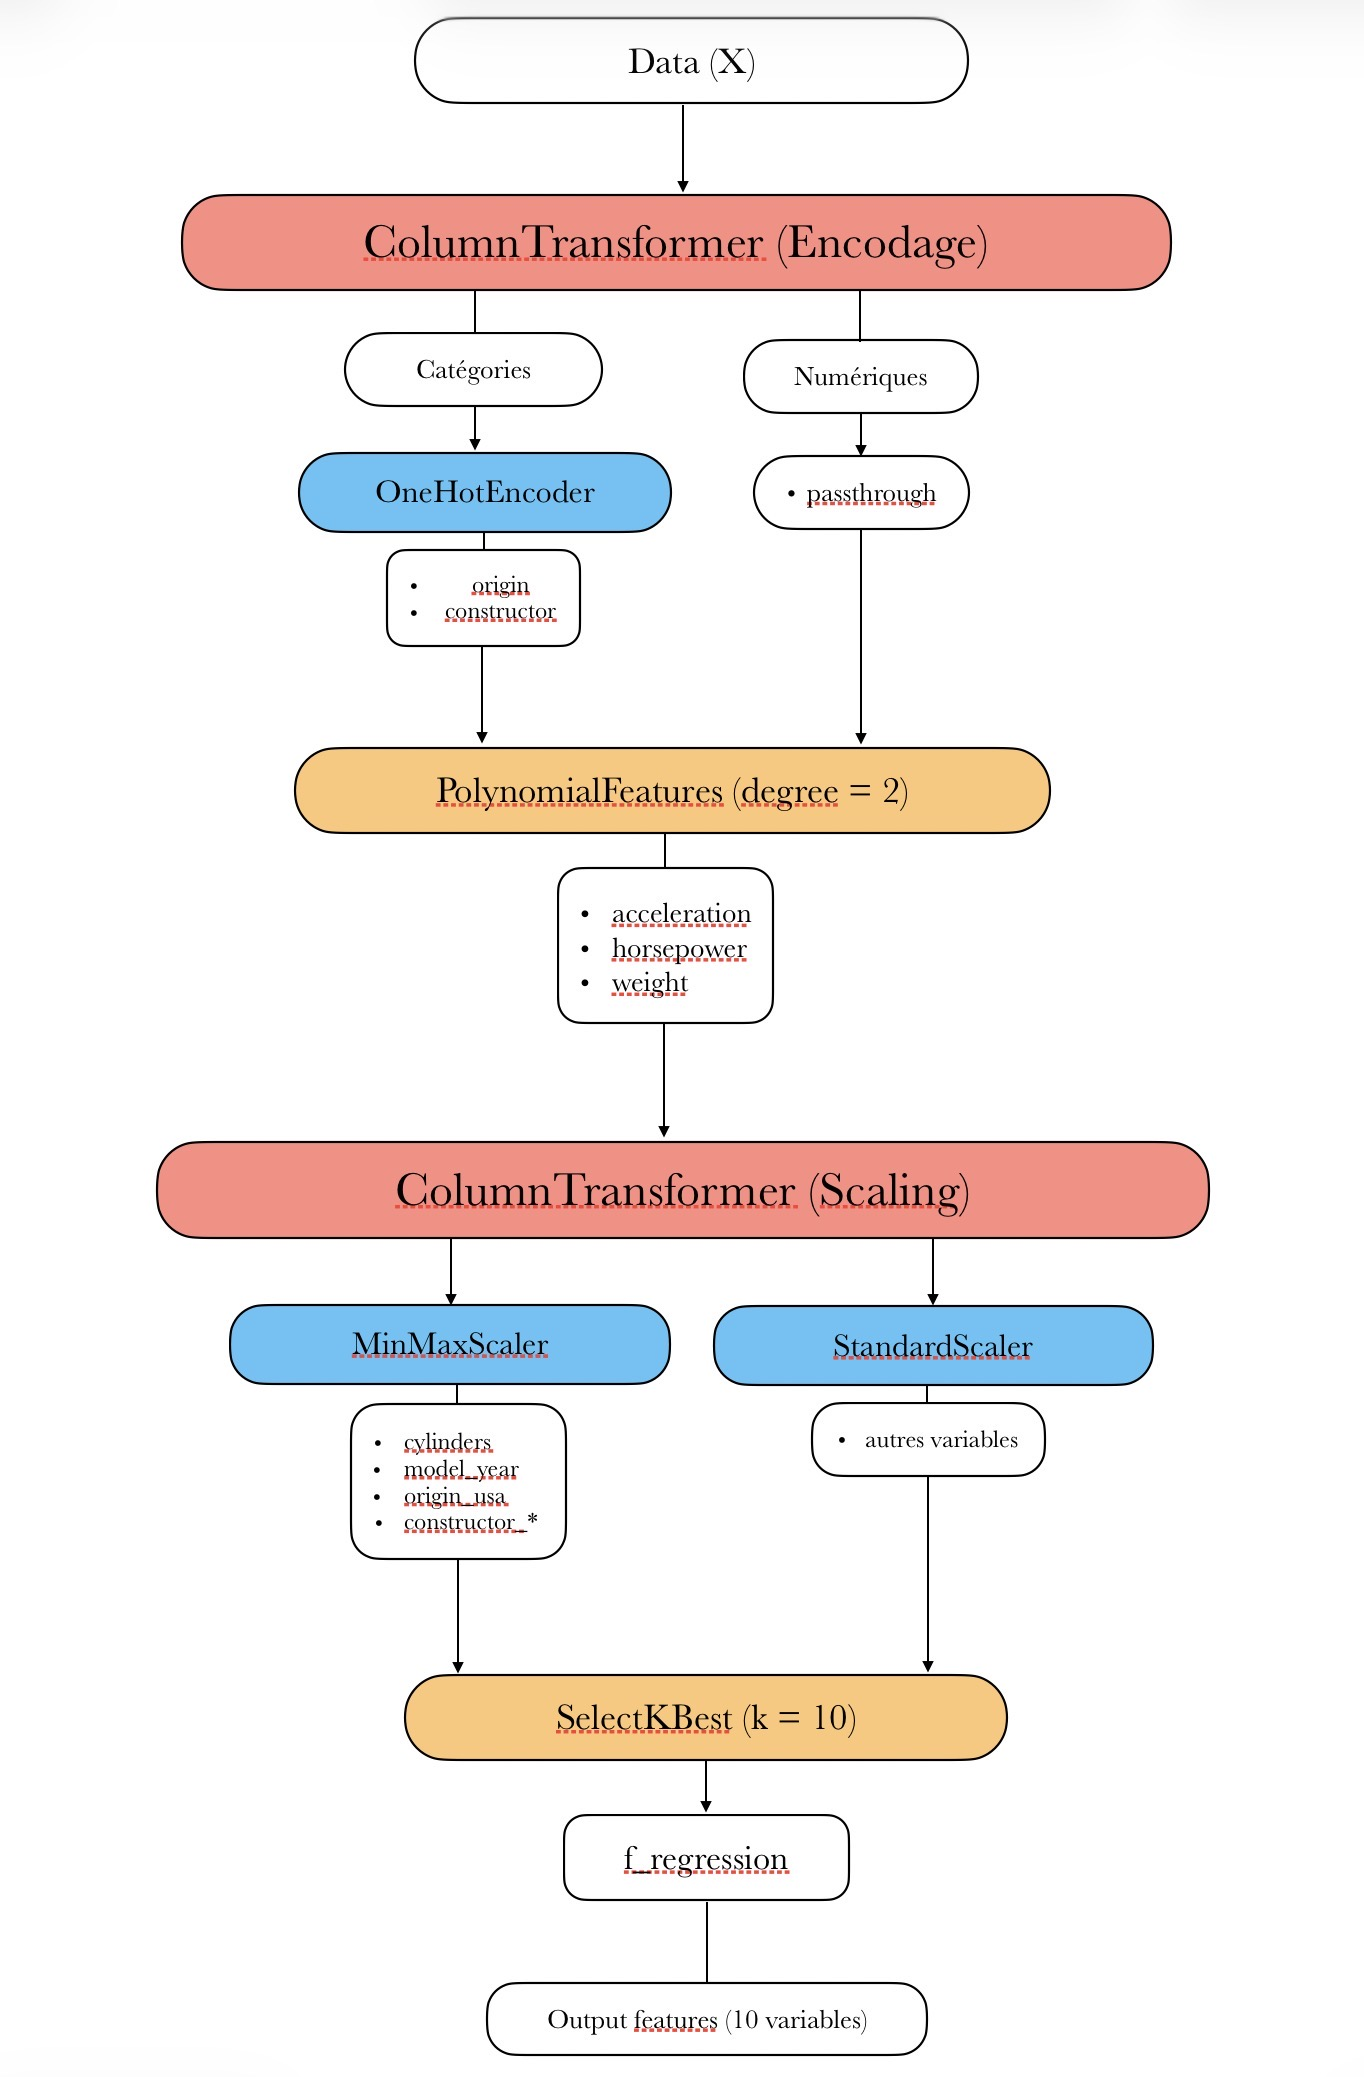

In [95]:
from IPython.display import Image, display

display(Image(filename="/Users/tatevikpiroyan/Documents/La Méthodologie de l'IA/images/pipeline_mpg.jpg"))

⚠️ une faute : **ColumnTransformer (PolynomialFeatures (degree = 2))** au lieu de **PolynomialFeatures (degree = 2)** !!!

<a id="pipeline"></a>

10. Mettre le tout dans une pipeline.

In [96]:
categorical_columns = ["origin", "constructor"]

column_transformer1 = ColumnTransformer(
    transformers=[
        ("Encoder", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), categorical_columns)
    ], 
    remainder="passthrough", 
    verbose_feature_names_out=False
)
column_transformer1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""

In [97]:
cols_polynomial = ["acceleration", "horsepower", "weight"]

column_transformer2 = ColumnTransformer(
    transformers=[
        ("PolynomialFeatures", PolynomialFeatures(degree=2, include_bias=False), cols_polynomial)
    ], 
    remainder="passthrough",
    verbose_feature_names_out=False
)
column_transformer2

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('PolynomialFeatures', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [98]:
def minmax_selector(X):
    cols = []
    for c in X.columns:
        if c in ["cylinders", "model_year"]:
            cols.append(c)
        # "usa" chez vous = origin_usa après OHE
        if c == "origin_usa":
            cols.append(c)
        # toutes les colonnes constructeur one-hot
        if c.startswith("constructor_"):
            cols.append(c)
    return cols

def standard_selector(X):
    mm = set(minmax_selector(X))
    return [c for c in X.columns if c not in mm]

column_transformer3 = ColumnTransformer(
    transformers=[
        ("MinMax", MinMaxScaler(), minmax_selector),
        ("Standard", StandardScaler(),standard_selector)
    ], 
    remainder="drop",
    verbose_feature_names_out=False
)
column_transformer3

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MinMax', ...), ('Standard', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [99]:
pipeline = Pipeline(steps=[
    ("Encoder", column_transformer1), 
    ("Feature Engineering", column_transformer2),
    ("Scaler", column_transformer3),
    ("Feature Selection",SelectKBest(score_func=f_regression, k=10))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Encoder', ...), ('Feature Engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [100]:
X_train = pipeline.fit_transform(X_train, y_train)
X_test  = pipeline.transform(X_test)

In [101]:
X_train.head()

,cylinders,model_year,horsepower,weight,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2,displacement
220,0.2,0.583333,-0.898424,-1.223229,-0.940398,-1.030761,-0.761244,-0.923153,-1.063718,-1.046114
256,0.6,0.666667,-0.105920,0.545070,0.434730,1.107089,-0.233104,0.030537,0.411211,0.312633
301,0.2,0.750000,-0.898424,-0.919582,-1.577406,-1.326097,-0.761244,-0.840855,-0.868405,-0.852007
193,0.6,0.500000,-0.607839,0.047327,-0.309457,0.620972,-0.589236,-0.426036,-0.086370,0.069999
57,0.2,0.166667,-0.238004,-0.826701,-0.190903,-0.816895,-0.334072,-0.553111,-0.803863,-0.774364


In [102]:
X_test.head()

,cylinders,model_year,horsepower,weight,acceleration horsepower,acceleration weight,horsepower^2,horsepower weight,weight^2,displacement
146,0.2,0.333333,-0.766340,-1.008890,-1.164109,-1.182125,-0.686165,-0.816073,-0.928345,-0.997587
282,0.2,0.750000,-0.422922,-0.097948,-0.064765,0.376142,-0.466728,-0.378326,-0.219423,-0.512321
69,1.0,0.166667,1.479086,1.766804,1.546966,1.201310,1.382383,1.736252,1.906311,1.525799
378,0.2,1.000000,-1.083341,-1.008890,-1.572098,-1.147604,-0.857655,-0.933642,-0.928345,-0.852007
331,0.2,0.833333,-0.977674,-0.985074,-0.864564,-0.548770,-0.803806,-0.888274,-0.912564,-0.929650


**********************************************************************

**********************************************************************